# Bandits with Saved Wine Recommenders

This notebook runs bandit policies using **saved recommendation outputs** from your model notebooks.

Expected arms (one per area):
- non-personalized: `popular_global_recs.csv`
- collaborative: `als_recs.csv`
- content-based: one of `content_tfidf_recs.csv`, `content_bow_recs.csv`, `content_lemma_tfidf_recs.csv`, `content_ner_tfidf_recs.csv`, `content_bert_recs.csv`


## 1) Setup

In [8]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from collections import defaultdict
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)


In [9]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for c in [start, *start.parents]:
        if (c / 'dataset').exists() and (c / 'bandits').exists():
            return c
    raise FileNotFoundError('Project root not found')

PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_DIR = PROJECT_ROOT / 'dataset'
ARMS_DIR = PROJECT_ROOT / 'bandits' / 'saved_arms'
RESULTS_DIR = PROJECT_ROOT / 'data' / 'results' / 'bandits'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('ARMS_DIR:', ARMS_DIR)


PROJECT_ROOT: /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system
ARMS_DIR: /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/bandits/saved_arms


## 2) Load ratings and build test rewards

Bandit reward is binary:
- `1` if chosen item is in user positive test set (`Rating >= 4`)
- `0` otherwise


In [10]:
ratings = pd.read_csv(
    DATASET_DIR / 'XWines_Full_21M_ratings.csv',
    usecols=['UserID', 'WineID', 'Rating'],
    dtype={'UserID': 'int32', 'WineID': 'int32', 'Rating': 'float32'}
)
ratings = ratings.drop_duplicates(subset=['UserID', 'WineID']).copy()

POSITIVE_THRESHOLD = 4.0
MIN_INTERACTIONS = 15
MAX_INTERACTIONS = 300
MAX_USERS = 1200
TEST_FRACTION = 0.2

print('ratings:', ratings.shape)
print('users total:', ratings['UserID'].nunique())



ratings: (20590800, 3)
users total: 1056079


In [11]:
def split_train_test_per_user(df, test_fraction=0.2, random_state=42):
    tr, te = [], []
    for _, g in df.groupby('UserID'):
        g = g.sample(frac=1.0, random_state=random_state)
        n_test = max(1, int(np.ceil(len(g) * test_fraction)))
        te_g, tr_g = g.iloc[:n_test], g.iloc[n_test:]
        if len(tr_g) == 0:
            continue
        tr.append(tr_g)
        te.append(te_g)
    return pd.concat(tr, ignore_index=True), pd.concat(te, ignore_index=True)



## 3) Load saved arm recommendations

Each saved file must have columns:
- `UserID`
- `rank`
- `WineID`


In [12]:
required_files = {
    'popular': ARMS_DIR / 'popular_global_recs.csv',
    'als': ARMS_DIR / 'als_recs.csv',
}

content_candidates = [
    ARMS_DIR / 'content_tfidf_recs.csv',
    ARMS_DIR / 'content_bow_recs.csv',
    ARMS_DIR / 'content_lemma_tfidf_recs.csv',
    ARMS_DIR / 'content_ner_tfidf_recs.csv',
    ARMS_DIR / 'content_bert_recs.csv',
]

missing = [str(p) for p in required_files.values() if not p.exists()]
if missing:
    raise FileNotFoundError('Missing required arm files:\n' + '\n'.join(missing))

content_file = next((p for p in content_candidates if p.exists()), None)
if content_file is None:
    raise FileNotFoundError('No content arm file found. Expected one of:\n' + '\n'.join(str(p) for p in content_candidates))

print('Using content arm file:', content_file.name)



Using content arm file: content_tfidf_recs.csv


In [13]:
def load_recs_map(path):
    df = pd.read_csv(path)
    cols = {'UserID', 'rank', 'WineID'}
    if not cols.issubset(df.columns):
        raise ValueError(f'{path} must contain columns {cols}')
    df = df.sort_values(['UserID', 'rank']).copy()
    rec_map = df.groupby('UserID')['WineID'].apply(lambda s: [int(x) for x in s.tolist()]).to_dict()
    return rec_map

arm_rec_maps = {
    'popular': load_recs_map(required_files['popular']),
    'als': load_recs_map(required_files['als']),
    'content': load_recs_map(content_file),
}

for arm, m in arm_rec_maps.items():
    print(f'{arm}: users={len(m)}')



popular: users=5000
als: users=5000
content: users=5000


In [14]:
# Build subset FROM arm users first (important fix)
users_pop = set(arm_rec_maps['popular'].keys())
users_als = set(arm_rec_maps['als'].keys())
users_content = set(arm_rec_maps['content'].keys())

users_from_arms = sorted(users_pop & users_als & users_content)
print('users common to all arm files:', len(users_from_arms))

if len(users_from_arms) == 0:
    raise ValueError('Arm files have no common users. Re-export arms with the same user set.')

subset = ratings[ratings['UserID'].isin(users_from_arms)].copy()

# apply same interaction filters on this aligned subset
user_counts = subset['UserID'].value_counts()
eligible_users = user_counts[(user_counts >= MIN_INTERACTIONS) & (user_counts <= MAX_INTERACTIONS)].index
subset = subset[subset['UserID'].isin(eligible_users)].copy()

# optional extra cap
if subset['UserID'].nunique() > MAX_USERS:
    sampled_users = rng.choice(subset['UserID'].unique(), size=MAX_USERS, replace=False)
    subset = subset[subset['UserID'].isin(sampled_users)].copy()

subset['reward'] = (subset['Rating'] >= POSITIVE_THRESHOLD).astype('int8')

train_df, test_df = split_train_test_per_user(subset, test_fraction=TEST_FRACTION, random_state=RANDOM_STATE)
test_relevant = test_df[test_df['reward'] == 1].groupby('UserID')['WineID'].apply(set).to_dict()

print('subset:', subset.shape)
print('subset users:', subset['UserID'].nunique())
print('train:', train_df.shape, 'test:', test_df.shape)
print('test users with positive items:', len(test_relevant))


users common to all arm files: 37
subset: (533, 4)
subset users: 13
train: (421, 4) test: (112, 4)
test users with positive items: 13


In [15]:
eligible_bandit_users = sorted(
    set(test_relevant.keys())
    & set(arm_rec_maps['popular'].keys())
    & set(arm_rec_maps['als'].keys())
    & set(arm_rec_maps['content'].keys())
)

print('eligible users for all arms:', len(eligible_bandit_users))
if len(eligible_bandit_users) == 0:
    raise ValueError('No overlapping users after split. Relax filters or re-export arm files.')


eligible users for all arms: 13


## 4) Bandit simulation (epsilon-greedy, UCB1, Thompson)


In [16]:
arm_names = ['popular', 'als', 'content']

def get_arm_item_for_user(user_id, arm, seen_dynamic, top_k=20):
    recs = arm_rec_maps[arm].get(user_id, [])[:top_k]
    seen = seen_dynamic[user_id]
    for wid in recs:
        if wid not in seen:
            return int(wid)
    return None


def run_bandit(policy='epsilon_greedy', n_rounds=3000, epsilon=0.15, c_ucb=1.2, random_state=42):
    r = np.random.default_rng(random_state)

    arm_counts = {a: 0 for a in arm_names}
    arm_rewards = {a: 0.0 for a in arm_names}
    alpha = {a: 1.0 for a in arm_names}
    beta = {a: 1.0 for a in arm_names}

    user_seen_dynamic = defaultdict(set)

    rows = []
    cum_reward = []
    cum_regret = []
    tr = 0.0
    tg = 0.0

    for t in range(1, n_rounds + 1):
        uid = int(r.choice(eligible_bandit_users))
        relevant = test_relevant.get(uid, set())

        candidates = {}
        expected = {}
        for a in arm_names:
            item = get_arm_item_for_user(uid, a, user_seen_dynamic, top_k=20)
            candidates[a] = item
            expected[a] = 0.0 if item is None else (1.0 if item in relevant else 0.0)

        if policy == 'epsilon_greedy':
            if r.random() < epsilon:
                chosen = r.choice(arm_names)
            else:
                means = {a: (arm_rewards[a]/arm_counts[a]) if arm_counts[a] > 0 else 0.0 for a in arm_names}
                chosen = max(means, key=means.get)
        elif policy == 'ucb1':
            scores = {}
            for a in arm_names:
                if arm_counts[a] == 0:
                    scores[a] = np.inf
                else:
                    mean = arm_rewards[a] / arm_counts[a]
                    scores[a] = mean + c_ucb * np.sqrt(np.log(t) / arm_counts[a])
            chosen = max(scores, key=scores.get)
        elif policy == 'thompson':
            sampled = {a: r.beta(alpha[a], beta[a]) for a in arm_names}
            chosen = max(sampled, key=sampled.get)
        else:
            raise ValueError('unknown policy')

        chosen_item = candidates[chosen]
        reward = expected[chosen]
        regret = max(expected.values()) - reward

        arm_counts[chosen] += 1
        arm_rewards[chosen] += reward
        if policy == 'thompson':
            alpha[chosen] += reward
            beta[chosen] += (1.0 - reward)

        if chosen_item is not None:
            user_seen_dynamic[uid].add(chosen_item)

        tr += reward
        tg += regret
        cum_reward.append(tr)
        cum_regret.append(tg)

        rows.append({'round': t, 'user_id': uid, 'chosen_arm': chosen, 'chosen_item': chosen_item, 'reward': reward, 'regret': regret})

    rounds_df = pd.DataFrame(rows)
    summary = {
        'policy': policy,
        'n_rounds': n_rounds,
        'total_reward': float(tr),
        'avg_reward': float(tr / n_rounds),
        'total_regret': float(tg),
        'avg_regret': float(tg / n_rounds),
    }
    for a in arm_names:
        c = arm_counts[a]
        rw = arm_rewards[a]
        summary[f'{a}_pulls'] = c
        summary[f'{a}_pull_share'] = c / n_rounds
        summary[f'{a}_mean_reward'] = (rw / c) if c > 0 else 0.0

    return rounds_df, pd.Series(summary), np.array(cum_reward), np.array(cum_regret)


In [17]:
N_ROUNDS = 3000

eps_rounds, eps_summary, eps_cum_reward, eps_cum_regret = run_bandit(
    policy='epsilon_greedy', n_rounds=N_ROUNDS, epsilon=0.15, random_state=RANDOM_STATE
)
ucb_rounds, ucb_summary, ucb_cum_reward, ucb_cum_regret = run_bandit(
    policy='ucb1', n_rounds=N_ROUNDS, c_ucb=1.2, random_state=RANDOM_STATE + 1
)
ths_rounds, ths_summary, ths_cum_reward, ths_cum_regret = run_bandit(
    policy='thompson', n_rounds=N_ROUNDS, random_state=RANDOM_STATE + 2
)

results = pd.concat([eps_summary, ucb_summary, ths_summary], axis=1).T.reset_index(drop=True)
display(results)


,policy,n_rounds,total_reward,avg_reward,total_regret,avg_regret,popular_pulls,popular_pull_share,popular_mean_reward,als_pulls,als_pull_share,als_mean_reward,content_pulls,content_pull_share,content_mean_reward
0,epsilon_greedy,3000,0.0,0.0,0.0,0.0,2683,0.894333,0.0,154,0.051333,0.0,163,0.054333,0.0
1,ucb1,3000,0.0,0.0,0.0,0.0,1000,0.333333,0.0,1000,0.333333,0.0,1000,0.333333,0.0
2,thompson,3000,0.0,0.0,0.0,0.0,993,0.331,0.0,999,0.333,0.0,1008,0.336,0.0


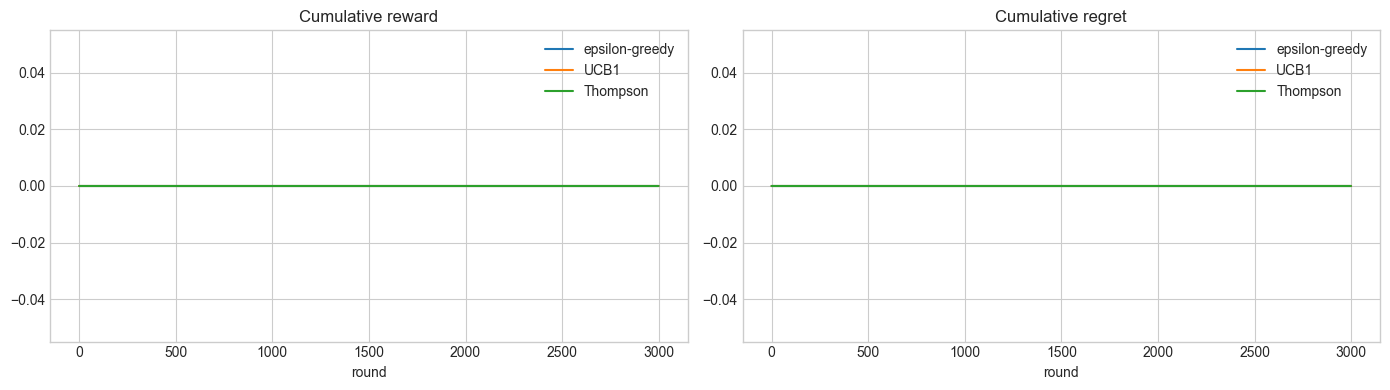

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(eps_cum_reward, label='epsilon-greedy')
axes[0].plot(ucb_cum_reward, label='UCB1')
axes[0].plot(ths_cum_reward, label='Thompson')
axes[0].set_title('Cumulative reward')
axes[0].set_xlabel('round')
axes[0].legend()

axes[1].plot(eps_cum_regret, label='epsilon-greedy')
axes[1].plot(ucb_cum_regret, label='UCB1')
axes[1].plot(ths_cum_regret, label='Thompson')
axes[1].set_title('Cumulative regret')
axes[1].set_xlabel('round')
axes[1].legend()

plt.tight_layout()
plt.show()


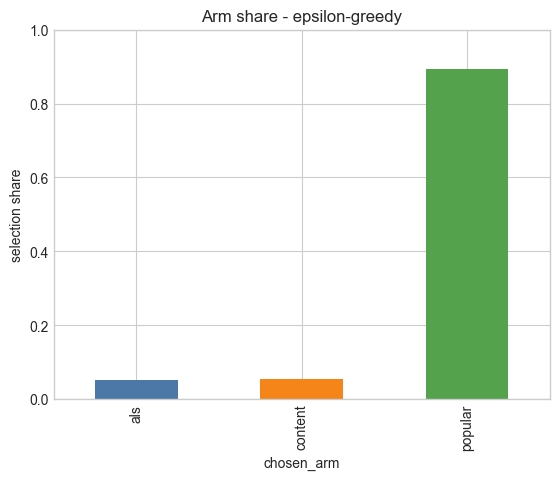

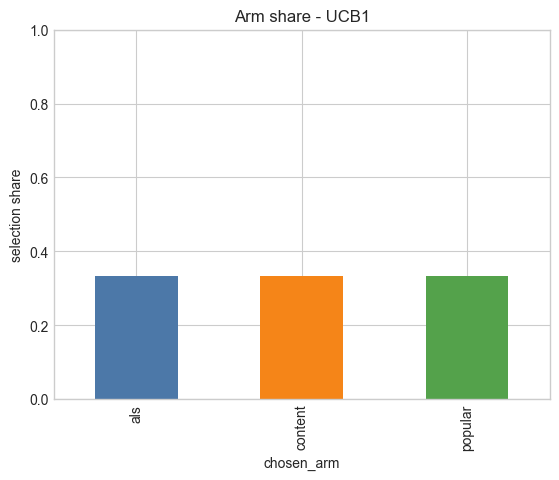

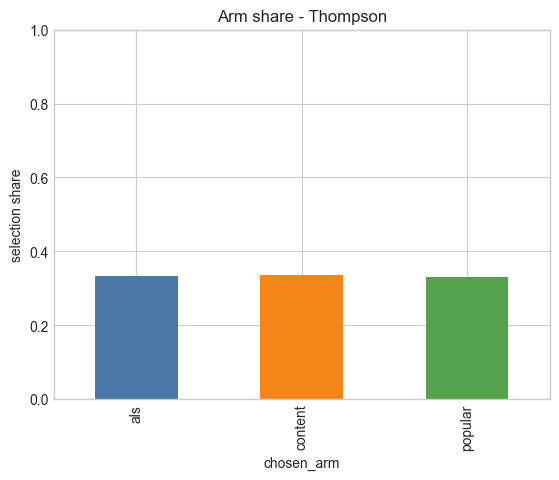

In [19]:
def plot_arm_share(df, title):
    share = df['chosen_arm'].value_counts(normalize=True).sort_index()
    share.plot(kind='bar', color=['#4C78A8', '#F58518', '#54A24B'])
    plt.title(title)
    plt.ylabel('selection share')
    plt.ylim(0, 1)
    plt.show()

plot_arm_share(eps_rounds, 'Arm share - epsilon-greedy')
plot_arm_share(ucb_rounds, 'Arm share - UCB1')
plot_arm_share(ths_rounds, 'Arm share - Thompson')


## 5) Save outputs

In [20]:
results.to_csv(RESULTS_DIR / 'bandit_policy_summary.csv', index=False)
eps_rounds.to_csv(RESULTS_DIR / 'bandit_rounds_epsilon_greedy.csv', index=False)
ucb_rounds.to_csv(RESULTS_DIR / 'bandit_rounds_ucb1.csv', index=False)
ths_rounds.to_csv(RESULTS_DIR / 'bandit_rounds_thompson.csv', index=False)

print('Saved:')
for f in sorted(RESULTS_DIR.glob('bandit_*')):
    print('-', f)


Saved:
- /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/bandits/bandit_policy_summary.csv
- /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/bandits/bandit_rounds_epsilon_greedy.csv
- /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/bandits/bandit_rounds_thompson.csv
- /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/bandits/bandit_rounds_ucb1.csv
